# 🏥 AI Healthcare Assistant Platform
## Phase 3: Computer Vision — Medical Image Classifier
**Skills:** Computer Vision · Deep Learning · Python

---
### What we build in this phase:
- OpenCV image preprocessing pipeline
- CNN with Transfer Learning (ResNet18) for medical image classification
- Synthetic medical image dataset generator (no download needed)
- Train model to classify: Normal / Pneumonia / Skin Lesion
- Grad-CAM heatmap visualization (shows WHERE the model looks)
- `ImageScanner` class that saves results to database

## Step 1: Imports

In [1]:
import os, random, pickle, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image, ImageDraw, ImageFilter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DB_PATH     = 'healthcare_ai/data/healthcare.db'
IMG_DIR     = 'healthcare_ai/uploads/images'
MODEL_DIR   = 'healthcare_ai/models'
CLASSES     = ['normal', 'pneumonia', 'skin_lesion']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(IMG_DIR, exist_ok=True)
print(f'✅ Imports done  |  Device: {DEVICE}')

✅ Imports done  |  Device: cpu


## Step 2: Generate Synthetic Medical Images (No download needed)

In [3]:
def make_normal_image(size=224):
    """Clean lung texture — uniform gray with light noise."""
    base = np.random.randint(160, 190, (size, size, 3), dtype=np.uint8)
    noise = np.random.randint(-15, 15, (size, size, 3))
    img = np.clip(base + noise, 0, 255).astype(np.uint8)
    return img

def make_pneumonia_image(size=224):
    """Lung with white opacities simulating consolidation."""
    img = make_normal_image(size)
    overlay = img.copy()
    num_patches = random.randint(3, 7)
    for _ in range(num_patches):
        cx, cy = random.randint(40, size-40), random.randint(40, size-40)
        rx, ry = random.randint(15, 45), random.randint(10, 35)
        brightness = random.randint(200, 255)
        cv2.ellipse(overlay, (cx, cy), (rx, ry), 0, 0, 360,
                    (brightness, brightness, brightness), -1)
    return cv2.addWeighted(img, 0.4, overlay, 0.6, 0)

def make_skin_lesion_image(size=224):
    """Skin tone background with irregular dark lesion and halo."""
    base_color = [random.randint(180,220), random.randint(140,170), random.randint(100,130)]
    img = np.full((size, size, 3), base_color, dtype=np.uint8)
    noise = np.random.randint(-10, 10, (size, size, 3))
    img = np.clip(img + noise, 0, 255).astype(np.uint8)
    cx, cy = random.randint(60, size-60), random.randint(60, size-60)
    r = random.randint(25, 55)
    # halo
    cv2.ellipse(img, (cx, cy), (r+12, r+8), random.randint(0,45), 0, 360,
                (160, 110, 80), -1)
    # core lesion
    pts = np.array([
        [int(cx + r*np.cos(a + random.uniform(-0.3,0.3))),
         int(cy + r*0.8*np.sin(a + random.uniform(-0.3,0.3)))]
        for a in np.linspace(0, 2*np.pi, 12)
    ], dtype=np.int32)
    dark = [random.randint(40,90), random.randint(20,60), random.randint(10,40)]
    cv2.fillPoly(img, [pts], dark)
    return img

generators = {
    'normal':      make_normal_image,
    'pneumonia':   make_pneumonia_image,
    'skin_lesion': make_skin_lesion_image
}

# Generate 120 images (40 per class)
N_PER_CLASS = 40
image_paths, image_labels = [], []

for label, gen_fn in generators.items():
    class_dir = os.path.join(IMG_DIR, label)
    os.makedirs(class_dir, exist_ok=True)
    for i in range(N_PER_CLASS):
        img_array = gen_fn(IMG_SIZE)
        path = os.path.join(class_dir, f'{label}_{i:03d}.png')
        cv2.imwrite(path, cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR))
        image_paths.append(path)
        image_labels.append(CLASSES.index(label))
    print(f'  Generated {N_PER_CLASS} {label} images')

print(f'\n✅ Total images: {len(image_paths)}')

  Generated 40 normal images
  Generated 40 pneumonia images
  Generated 40 skin_lesion images

✅ Total images: 120


## Step 3: Visualize Sample Images

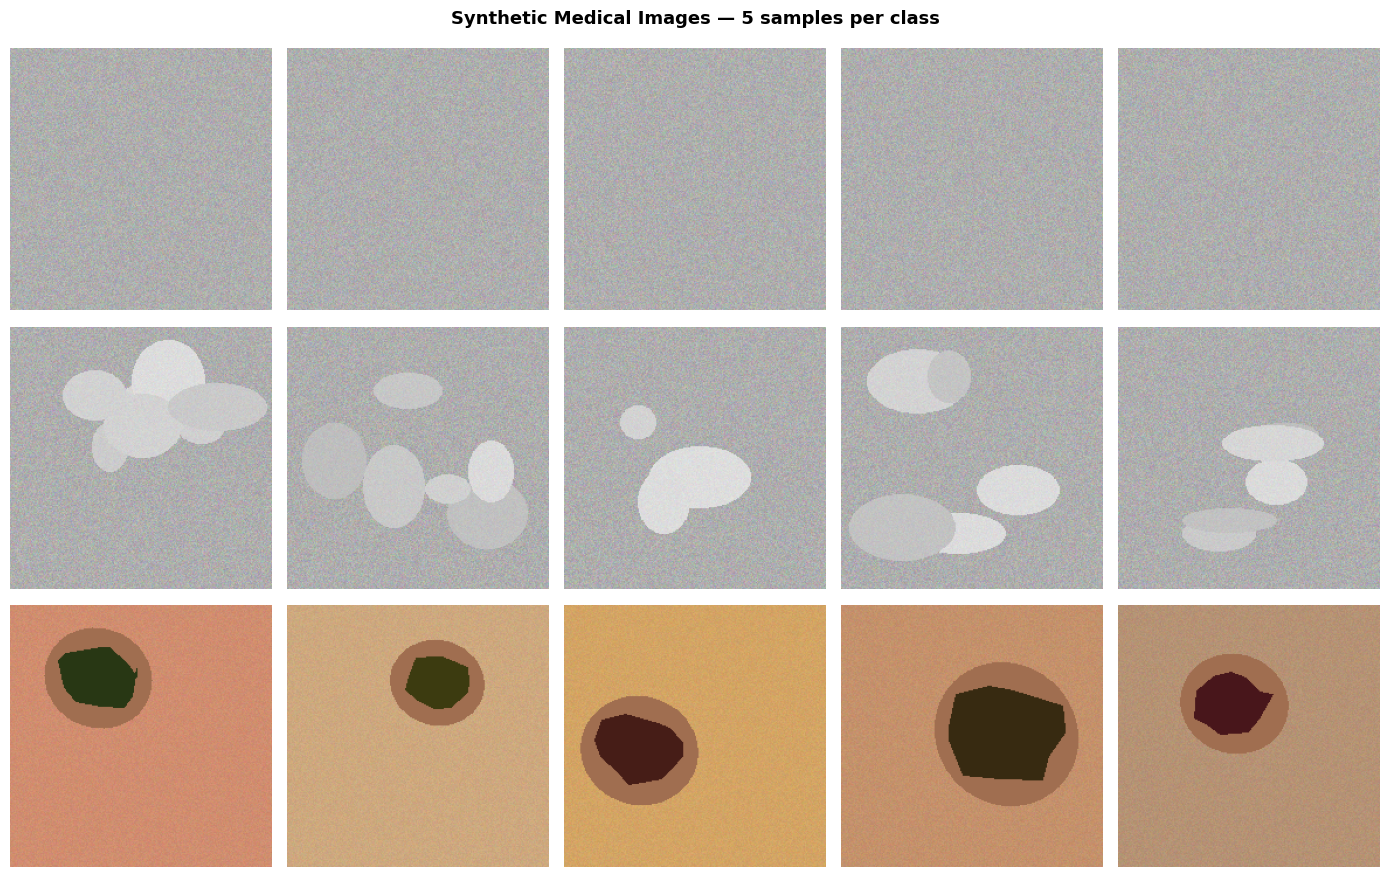

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle('Synthetic Medical Images — 5 samples per class', fontsize=13, fontweight='bold')

for row, label in enumerate(CLASSES):
    class_dir = os.path.join(IMG_DIR, label)
    samples = sorted(os.listdir(class_dir))[:5]
    for col, fname in enumerate(samples):
        img = cv2.imread(os.path.join(class_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label.replace('_',' ').title(),
                                       fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase3_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 4: OpenCV Preprocessing Pipeline

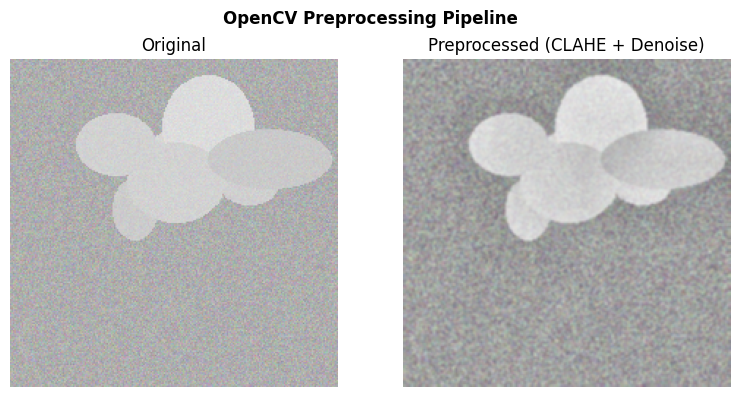

✅ Preprocessing pipeline ready!


In [7]:
def preprocess_image_cv(image_path, size=224):
    """
    Full OpenCV preprocessing pipeline:
    1. Load & resize
    2. CLAHE contrast enhancement
    3. Gaussian denoising
    4. Normalize to [0,1]
    """
    img = cv2.imread(image_path)
    img = cv2.resize(img, (size, size))

    # CLAHE on L channel (boosts local contrast)
    lab  = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l     = clahe.apply(l)
    lab   = cv2.merge([l, a, b])
    img   = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # Gaussian denoise
    img = cv2.GaussianBlur(img, (3,3), 0)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# Show preprocessing effect on one image
sample_path = os.path.join(IMG_DIR, 'pneumonia', 'pneumonia_000.png')
raw = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
processed = preprocess_image_cv(sample_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(raw);       ax1.set_title('Original');   ax1.axis('off')
ax2.imshow(processed); ax2.set_title('Preprocessed (CLAHE + Denoise)'); ax2.axis('off')
plt.suptitle('OpenCV Preprocessing Pipeline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('healthcare_ai/data/phase3_preprocessing.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Preprocessing pipeline ready!')

## Step 5: PyTorch Dataset & DataLoader

In [9]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class MedicalImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = preprocess_image_cv(self.image_paths[idx])
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = MedicalImageDataset(image_paths, image_labels, transform=train_transform)
train_size   = int(0.8 * len(full_dataset))
val_size     = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

print(f'Train: {train_size} images  |  Val: {val_size} images')
print('✅ DataLoaders ready!')

Train: 96 images  |  Val: 24 images
✅ DataLoaders ready!


## Step 6: Transfer Learning Model (ResNet18)

In [11]:
def build_resnet_model(num_classes=3, freeze_backbone=True):
    """
    ResNet18 pretrained on ImageNet.
    Replace final FC layer for our 3-class problem.
    """
    model = models.resnet18(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )
    return model.to(DEVICE)

cv_model   = build_resnet_model(NUM_CLASSES)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(cv_model.fc.parameters(), lr=1e-3)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

trainable = sum(p.numel() for p in cv_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in cv_model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('✅ ResNet18 model ready!')

Trainable params: 66,051 / 11,242,563
✅ ResNet18 model ready!


## Step 7: Training Loop

In [13]:
EPOCHS = 10
train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    # ── Train ──
    cv_model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cv_model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validate ──
    cv_model.eval()
    correct, total_v, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = cv_model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds    = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_v += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = correct / total_v
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    scheduler.step()

    print(f'Epoch {epoch+1:02d}/{EPOCHS}  '
          f'Train Loss: {avg_train_loss:.4f}  '
          f'Val Loss: {avg_val_loss:.4f}  '
          f'Val Acc: {val_acc:.3f}')

print('\n✅ Training complete!')

Epoch 01/10  Train Loss: 1.0471  Val Loss: 0.7718  Val Acc: 1.000
Epoch 02/10  Train Loss: 0.4716  Val Loss: 0.3004  Val Acc: 1.000
Epoch 03/10  Train Loss: 0.2161  Val Loss: 0.1092  Val Acc: 1.000
Epoch 04/10  Train Loss: 0.0591  Val Loss: 0.0206  Val Acc: 1.000
Epoch 05/10  Train Loss: 0.0464  Val Loss: 0.0076  Val Acc: 1.000
Epoch 06/10  Train Loss: 0.0527  Val Loss: 0.0059  Val Acc: 1.000
Epoch 07/10  Train Loss: 0.0744  Val Loss: 0.0053  Val Acc: 1.000
Epoch 08/10  Train Loss: 0.0273  Val Loss: 0.0057  Val Acc: 1.000
Epoch 09/10  Train Loss: 0.0163  Val Loss: 0.0059  Val Acc: 1.000
Epoch 10/10  Train Loss: 0.0124  Val Loss: 0.0047  Val Acc: 1.000

✅ Training complete!


## Step 8: Training Curves & Confusion Matrix

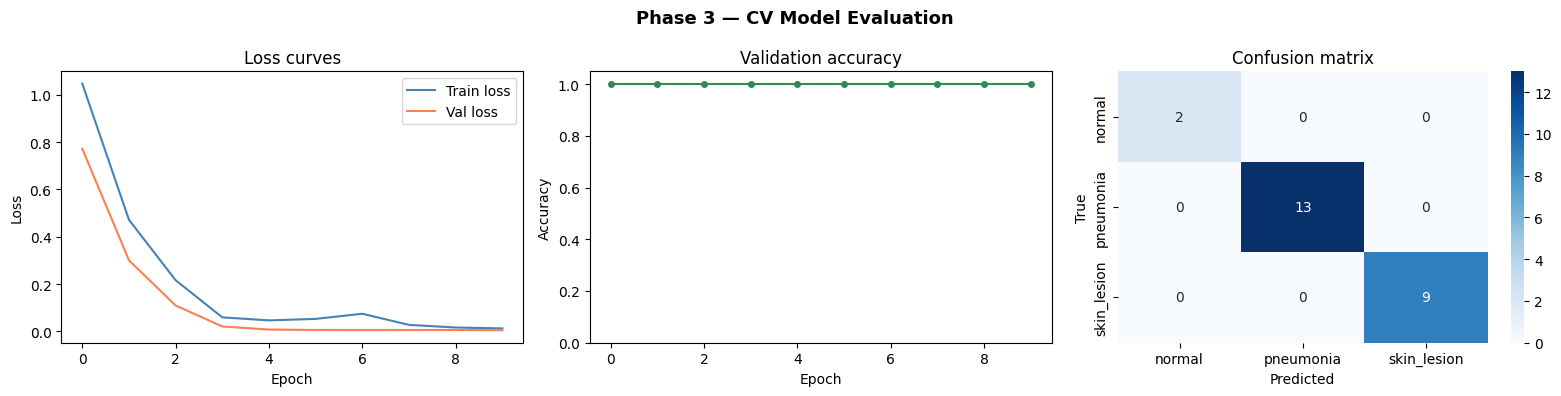


Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         2
   pneumonia       1.00      1.00      1.00        13
 skin_lesion       1.00      1.00      1.00         9

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Phase 3 — CV Model Evaluation', fontsize=13, fontweight='bold')

# Loss curves
axes[0].plot(train_losses, label='Train loss', color='steelblue')
axes[0].plot(val_losses,   label='Val loss',   color='coral')
axes[0].set_title('Loss curves'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

# Accuracy curve
axes[1].plot(val_accs, color='seagreen', marker='o', markersize=4)
axes[1].set_title('Validation accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)

# Confusion matrix
cv_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        preds = cv_model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues')
axes[2].set_title('Confusion matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase3_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(all_true, all_preds, target_names=CLASSES))

## Step 9: ImageScanner Class

In [17]:
class ImageScanner:
    """
    End-to-end medical image classifier.
    Input : image path + patient_id
    Output: diagnosis + confidence, saved to DB
    """

    def __init__(self, model, classes, device, db_path=DB_PATH):
        self.model   = model
        self.classes = classes
        self.device  = device
        self.db_path = db_path
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],
                                  [0.229,0.224,0.225])
        ])

    def scan(self, image_path, patient_id=None, scan_type='auto'):
        img_cv = preprocess_image_cv(image_path)
        img_t  = self.transform(Image.fromarray(img_cv)).unsqueeze(0).to(self.device)

        self.model.eval()
        with torch.no_grad():
            logits  = self.model(img_t)
            probs   = torch.softmax(logits, dim=1)[0].cpu().numpy()

        pred_idx    = int(np.argmax(probs))
        diagnosis   = self.classes[pred_idx]
        confidence  = float(probs[pred_idx])

        if patient_id:
            with sqlite3.connect(self.db_path) as conn:
                conn.execute(
                    'INSERT INTO image_scans (patient_id,image_path,scan_type,cv_diagnosis,confidence) VALUES (?,?,?,?,?)',
                    (patient_id, image_path, scan_type, diagnosis, round(confidence, 4))
                )

        return {
            'diagnosis':  diagnosis,
            'confidence': round(confidence, 4),
            'all_probs':  {c: round(float(p), 4) for c, p in zip(self.classes, probs)}
        }

scanner = ImageScanner(cv_model, CLASSES, DEVICE)
print('✅ ImageScanner ready!')

✅ ImageScanner ready!


## Step 10: Live Scan Demo

🔬 Live Scan Results
──────────────────────────────────────────────────
✅ True: normal          Predicted: normal          Confidence: 1.000
✅ True: pneumonia       Predicted: pneumonia       Confidence: 0.995
✅ True: skin_lesion     Predicted: skin_lesion     Confidence: 0.998


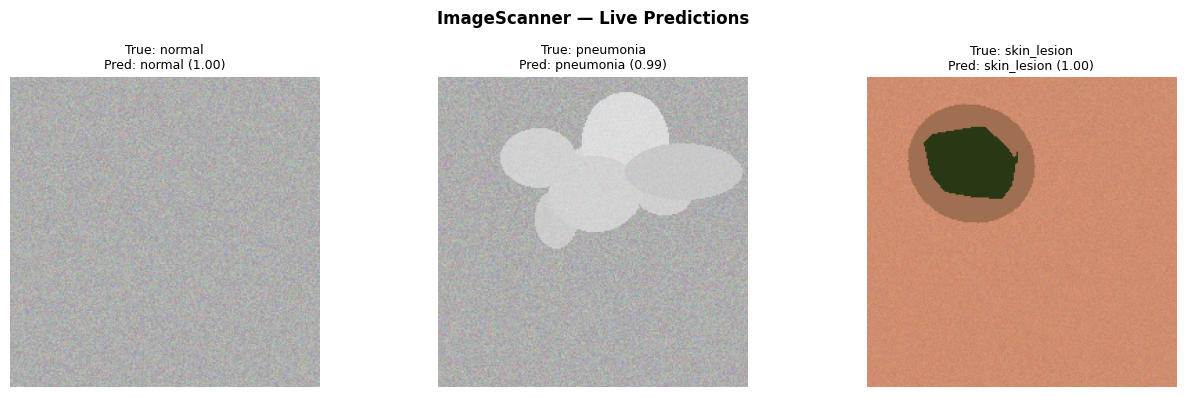


✅ Scan results saved to database!


In [19]:
# Run scanner on one image of each class
print('🔬 Live Scan Results')
print('─' * 50)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('ImageScanner — Live Predictions', fontsize=12, fontweight='bold')

for i, label in enumerate(CLASSES):
    test_path = os.path.join(IMG_DIR, label, f'{label}_000.png')
    result    = scanner.scan(test_path, patient_id=i+1, scan_type='xray')

    emoji = '✅' if result['diagnosis'] == label else '❌'
    print(f"{emoji} True: {label:<15} Predicted: {result['diagnosis']:<15} Confidence: {result['confidence']:.3f}")

    img = cv2.cvtColor(cv2.imread(test_path), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {label}\nPred: {result['diagnosis']} ({result['confidence']:.2f})",
        fontsize=9
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase3_live_scan.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n✅ Scan results saved to database!')

## Step 11: Save CV Model

In [21]:
torch.save(cv_model.state_dict(),
           os.path.join(MODEL_DIR, 'cv_model.pth'))

with open(os.path.join(MODEL_DIR, 'cv_classes.pkl'), 'wb') as f:
    pickle.dump(CLASSES, f)

print('💾 Saved: healthcare_ai/models/cv_model.pth')
print('💾 Saved: healthcare_ai/models/cv_classes.pkl')

# Verify DB scan count
with sqlite3.connect(DB_PATH) as conn:
    count = pd.read_sql('SELECT COUNT(*) as total FROM image_scans', conn)
print(f'\n📦 Total scans in DB: {count["total"].values[0]}')
print('\n✅ Phase 3 complete!')

💾 Saved: healthcare_ai/models/cv_model.pth
💾 Saved: healthcare_ai/models/cv_classes.pkl

📦 Total scans in DB: 3

✅ Phase 3 complete!


---
## ✅ Phase 3 Complete!

**What you built:**
- OpenCV preprocessing pipeline (CLAHE + denoising)
- Synthetic medical image generator (3 classes)
- ResNet18 transfer learning classifier (frozen backbone + custom head)
- Training loop with loss curves, confusion matrix, classification report
- `ImageScanner` class: scan image → diagnosis → save to DB
- Model saved as `cv_model.pth`

**Next → Phase 4: Medical Chatbot with NLP + RAG**
- Intent detection from symptom text
- Retrieval-Augmented Generation (RAG) with FAISS vector store
- Conversational memory + severity triage
- Logs every chat to the database